#### Notebook to analyze videos to find contours across an entire night

In [1]:
# Import required functions from the script
import sys
sys.path.append('..\..\scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos

In [3]:
# ---- Pipeline Configuration ----
# Set all paths and filenames here for easy reuse

# Experiment ID (used in filenames)
exp_id = "041625PA" #Also change date in base_dir below

# Base directories
base_dir = f"D:\AprPanama2025_fixed\\041625_experimental"
results_dir = "..\..\\results"
scripts_dir = "..\\..\\scripts"

# Video pattern and output files
video_pattern = f"{base_dir}\\{exp_id}_experimental_part??.mp4"
output_file = f"{results_dir}\\contours_{exp_id}_experimental_fixed.tab"

# Visualization parameters
black = 110
minArea = 1.5
maxArea = 1000.0
brightnessThreshold = 50
threads = 4
maxy = None

# Check what video files exist
import os
print("Files in base_dir:")
for f in os.listdir(base_dir):
    print(f)

Files in base_dir:
041625PA_experimental_part01.mp4
041625PA_experimental_part02.mp4
041625PA_experimental_part03.mp4
041625PA_experimental_part04.mp4
041625PA_experimental_part05.mp4
041625PA_experimental_part06.mp4
041625PA_experimental_part07.mp4
041625PA_experimental_part08.mp4
041625PA_experimental_part09.mp4
041625PA_experimental_part10.mp4
041625PA_experimental_part11.mp4
041625PA_experimental_part12.mp4
041625PA_experimental_part13.mp4
041625PA_experimental_part14.mp4
041625PA_experimental_part15.mp4
041625PA_experimental_part16.mp4
041625PA_experimental_part17.mp4
041625PA_experimental_part18.mp4
041625PA_experimental_part19.mp4
041625PA_experimental_part20.mp4
041625PA_experimental_part21.mp4
041625PA_experimental_part22.mp4
041625PA_experimental_part23.mp4
041625PA_experimental_part24.mp4
041625PA_experimental_part25.mp4
041625PA_experimental_part26.mp4
process_log_20260308_173813.txt
video_audit_20260308_173813.csv


### First find the video and frame number where the lights turn off

In [4]:
import subprocess
import cv2
import re
import pandas as pd
import os
import sys

video_path = f"{base_dir}\\{exp_id}_experimental_part03.mp4"

print("Video path:", video_path)
print("File exists:", os.path.exists(video_path))

# Use ffmpeg from conda environment
conda_env_path = os.path.dirname(sys.executable)
ffmpeg_path = os.path.join(conda_env_path, 'Library', 'bin', 'ffmpeg.exe')

cmd = [
    ffmpeg_path,  # Use full path from conda
    '-hide_banner', '-nostats', '-i', video_path,
    '-vf', 'blackdetect=d=0.5:pix_th=0.10',
    '-an', '-f', 'null', '-'
]

try:
    result = subprocess.run(cmd, capture_output=True, text=True, check=False)
    output = result.stderr
    
    lines = output.split('\n')
    black_lines = [line for line in lines if 'black_start' in line]
    
    if black_lines:
        line = black_lines[-1].strip()
        print(f"Found black detection line:\n{line}\n")
        
        match = re.search(r'black_start:(\d+\.\d+)\s+black_end:(\d+\.\d+)\s+black_duration:(\d+\.?\d*)', line)
        if match:
            black_start = float(match.group(1))
            black_end = float(match.group(2))
            black_duration = float(match.group(3))
            print(f"✓ Successfully extracted: start={black_start}, end={black_end}, duration={black_duration}")
        else:
            black_start = black_end = black_duration = None
    else:
        print("✗ No black_start lines found")
        black_start = black_end = black_duration = None
        
except Exception as e:
    print(f"✗ Error: {e}")
    black_start = black_end = black_duration = None

# Rest of your code...
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
total_length = frame_count / fps if fps else None

def sec_to_mmss(seconds):
    if seconds is None:
        return ""
    m, s = divmod(int(seconds), 60)
    return f"{m:02d}:{s:02d}"

def sec_to_frame(seconds, fps):
    if seconds is None or not fps:
        return ""
    return int(round(seconds * fps))

table = [
    {"event": "total_length", "frame": frame_count, "time (mm:ss)": sec_to_mmss(total_length)},
    {"event": "blackstart", "frame": sec_to_frame(black_start, fps), "time (mm:ss)": sec_to_mmss(black_start)},
    {"event": "blackend", "frame": sec_to_frame(black_end, fps), "time (mm:ss)": sec_to_mmss(black_end)},
    {"event": "blackduration", "frame": sec_to_frame(black_duration, fps), "time (mm:ss)": sec_to_mmss(black_duration)},
]

darkness = pd.DataFrame(table)

Video path: D:\AprPanama2025_fixed\041625_experimental\041625PA_experimental_part03.mp4
File exists: True
Found black detection line:
[blackdetect @ 000001B8BB548900] black_start:960.4 black_end:1799.9 black_duration:839.5

✓ Successfully extracted: start=960.4, end=1799.9, duration=839.5


In [5]:
print("Video Information")
print(f"FPS: {fps}")
print(f"Video duration (s): {total_length}")
print(darkness)
print("\n")

Video Information
FPS: 10.0
Video duration (s): 1800.0
           event  frame time (mm:ss)
0   total_length  18000        30:00
1     blackstart   9604        16:00
2       blackend  17999        29:59
3  blackduration   8395        13:59




### Here, manually find borders of tanks

Script ran successfully!


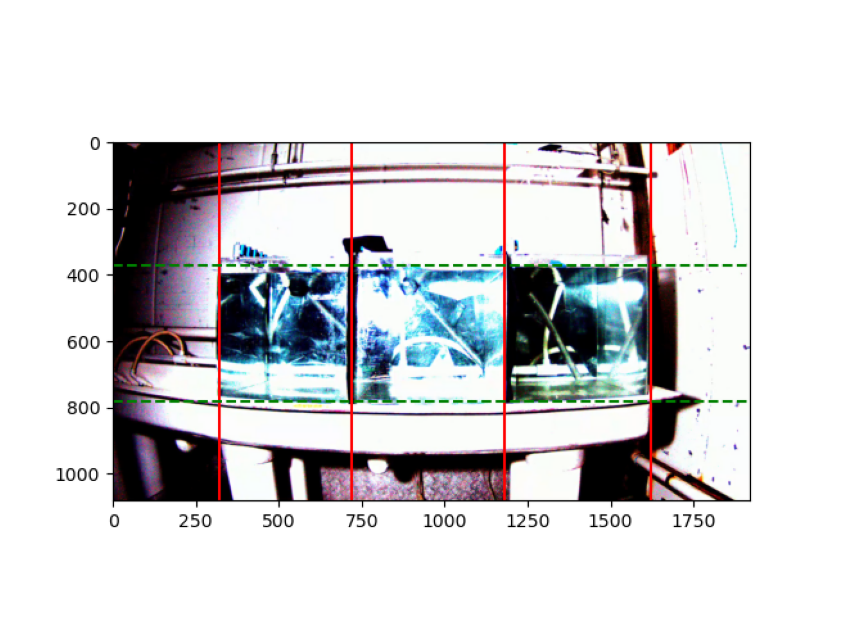

In [6]:
import subprocess
import matplotlib.pyplot as plt
import cv2
import os
import sys

# Manually iterate these numbers to identify borders of tanks
x_lines = [320, 720, 1180, 1620]
y_lines = [370, 780]

# Extract xlim and ylim from x_lines and y_lines from manual numbers above
xlim = [x_lines[0], x_lines[-1]]
ylim = [y_lines[0], y_lines[-1]]

# Parameters
video_path = f"{base_dir}\\{exp_id}_experimental_part01.mp4"
frame_number = 500
output_image = f"{results_dir}\\{exp_id}_experimental_fixed.png"

# Build command using the CURRENT Python interpreter (which has cv2)
cmd = [
    sys.executable,  # Use the same Python that's running this notebook
    f'{scripts_dir}\\visualize_tanx.py',
    '-v', video_path,
    '-f', str(frame_number),
    '-t', *map(str, x_lines),
    '-y', *map(str, y_lines),
    '-o', output_image
]

# Run the script WITH error capture
try:
    result = subprocess.run(cmd, check=True, capture_output=True, text=True)
    print("Script ran successfully!")
except subprocess.CalledProcessError as e:
    print("=" * 60)
    print("SCRIPT FAILED - HERE'S THE ERROR:")
    print("=" * 60)
    print("\nSTDOUT:")
    print(e.stdout if e.stdout else "(no stdout)")
    print("\nSTDERR:")
    print(e.stderr if e.stderr else "(no stderr)")
    print(f"\nReturn code: {e.returncode}")
    print("=" * 60)

# Display the image in the notebook
if os.path.exists(output_image):
    img = cv2.imread(output_image)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Visualization image not found.')

In [7]:
# ---- Checks if contours output file already exists and if not runs find_contours.py ----

import os


redo = False  # Set to True to force overwrite

if os.path.exists(output_file) and not redo:
    print(f"Output file '{output_file}' already exists. Skipping contour extraction.")
else:
    print(f"Running contour extraction. Output will be saved to '{output_file}'.")
    results = find_contours_from_videos(
        video_pattern=video_pattern,
        black=black,
        minArea=minArea,
        maxArea=maxArea,
        brightnessThreshold=brightnessThreshold,
        threads=threads,
        outfile=output_file,
        maxy=maxy,
        xlim=xlim,
        ylim=ylim
    )
    print(f'Contour results written to {output_file}')

Output file '..\..\results\contours_041625PA_experimental_fixed.tab' already exists. Skipping contour extraction.


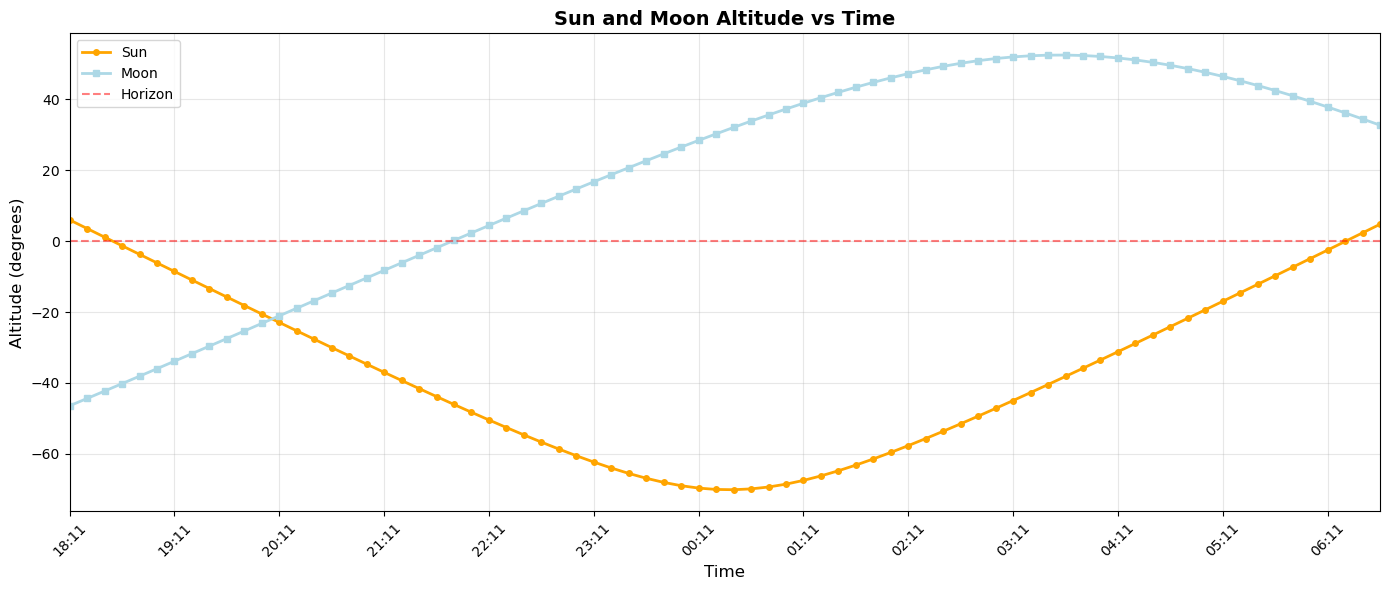

SUN AND MOON POSITION SUMMARY
Observation Period: 2025-04-16 18:11:00 EST to 2025-04-17 06:49:00 EST
Observer Location: Latitude 9.338212°, Longitude -82.258937°
Timezone: America/Panama

Sun Statistics:
  Maximum Altitude: 5.97°
  Minimum Altitude: -70.09°
  Time of Max Altitude (Solar Noon): 18:11 (Local Time)
  Azimuth Range: 1.75° to 354.54°
  Sunrise: 06:26:00 EST
  Sunset: 18:36:00 EST

Twilight Times:
  Civil Twilight Start: 06:01:00 EST
  Civil Twilight End: 19:01:00 EST
  Nautical Twilight Start: 05:36:00 EST
  Nautical Twilight End: 19:26:00 EST
  Astronomical Twilight Start: 05:11:00 EST
  Astronomical Twilight End: 19:51:00 EST

Moon Statistics:
  Maximum Altitude: 52.45°
  Minimum Altitude: -46.42°
  Time of Max Altitude: 03:41 (Local Time)
  Azimuth Range: 115.54° to 227.46°
  Moonrise: 21:51:00 EST

  (0°=North, 90°=East, 180°=South, 270°=West)
Graph saved to: ..\..\results\position_041625PA_experimental_fixed.png


In [8]:
import importlib
import matplotlib.pyplot as plt
import sun_moon_position_plot

importlib.reload(sun_moon_position_plot)

from sun_moon_position_plot import plot_sun_moon_position

fig = plot_sun_moon_position(
    start_date='2025-04-16',
    start_time='18:11:00',
    end_date='2025-04-17',
    end_time='06:49:00',
    latitude=9.338212,
    longitude=-82.258937
)

# Export the graph
output_path = f"{results_dir}\\position_{exp_id}_experimental_fixed.png"
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Graph saved to: {output_path}")

In [11]:
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import os

# Load the tab-separated file
df = pd.read_csv(output_file, sep='\t')

# Convert frames to time (10 fps, starting recording time)
start_time = datetime.strptime('17:33:00', '%H:%M:%S')
df['time'] = df['frame'].apply(lambda x: start_time + timedelta(seconds=x/10))

# Filter data for time range that the lights were on
time_start = datetime.strptime('18:11:00', '%H:%M:%S')
time_end = datetime.strptime('06:49:00', '%H:%M:%S')

# Since 6:49 AM is the next day, add 1 day to time_end
time_end = time_end + timedelta(days=1)

df_filtered = df[(df['time'] >= time_start) & (df['time'] <= time_end)]

# Apply x-coordinate offset to convert to original coordinates
xlim_offset = x_lines[0]  # Auto-calculate from first x_line
df_filtered['cX_original'] = df_filtered['cX'] + xlim_offset

# Filter data for x coordinates in tanks
df_filtered = df_filtered[(df_filtered['cX_original'] >= x_lines[0]) & (df_filtered['cX_original'] <= x_lines[-1])]

#Save filtered dataframe for statistics
df_filtered.to_csv('..\..\\results\\April16_contours_filtered.csv', index=False) 

Figure saved to '..\..\results\041625PA_contour_plot.png'


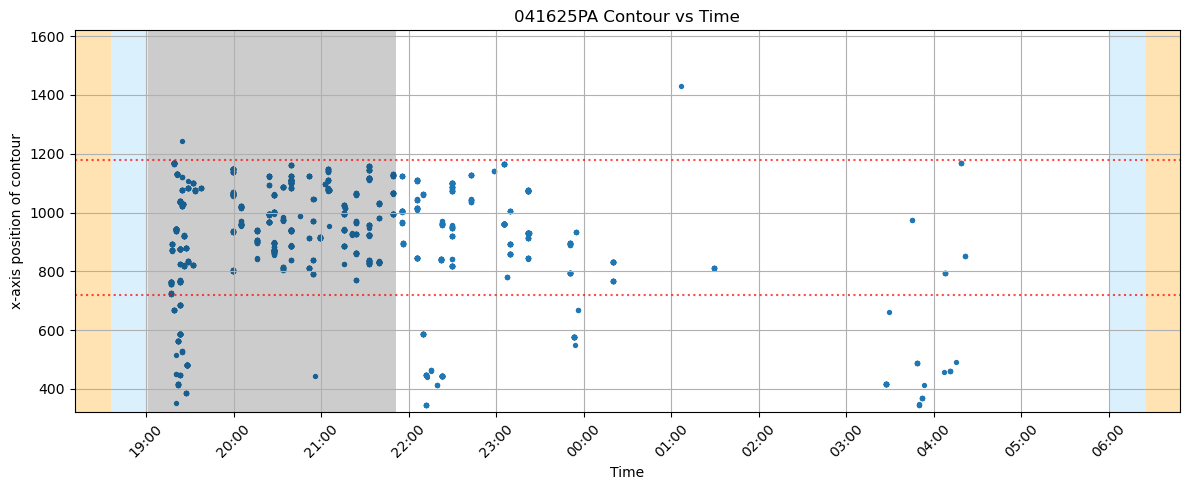

In [12]:
# Plot time vs cX (using original coordinates)
plt.figure(figsize=(12, 5))
plt.scatter(df_filtered['time'], df_filtered['cX_original'], s=8)
plt.xlabel('Time')
plt.ylabel('x-axis position of contour')
plt.title(f'{exp_id} Contour vs Time')

# Format x-axis to show only time with hourly ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator())  # Set ticks every hour
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

# Set x-axis limits to ensure the graph extends to 6:49 AM
ax.set_xlim(time_start, time_end)

# Add dotted lines at specified x coordinates (cutoffs)
x_coordinates = x_lines[1:-1]  # Use the inner x_lines for cutoffs
for x in x_coordinates:
    ax.axhline(y=x, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Add transparent box for sunset day period
box_start1 = datetime.strptime(time_start.strftime('%H:%M:%S'), '%H:%M:%S')
box_end1 = datetime.strptime('18:36:00', '%H:%M:%S')
rect = mpatches.Rectangle((box_start1, x_lines[0]), box_end1 - box_start1, x_lines[-1] - x_lines[0], 
                          linewidth=0, edgecolor='none', facecolor='orange', alpha=0.3)
ax.add_patch(rect)

# Add transparent box for sunrise day period
box_start2 = datetime.strptime('06:26:00', '%H:%M:%S') + timedelta(days=1)
box_end2 = datetime.strptime(time_end.strftime('%H:%M:%S'), '%H:%M:%S') + timedelta(days=1)
rect = mpatches.Rectangle((box_start2, x_lines[0]), box_end2 - box_start2, x_lines[-1] - x_lines[0], 
                          linewidth=0, edgecolor='none', facecolor='orange', alpha=0.3)
ax.add_patch(rect)

# Add transparent box for sunset - civil twilight
box_end3 = datetime.strptime('19:01:00', '%H:%M:%S')
rect = mpatches.Rectangle((box_end1, x_lines[0]), box_end3 - box_end1, x_lines[-1] - x_lines[0], 
                          linewidth=0, edgecolor='none', facecolor='lightskyblue', alpha=0.3)
ax.add_patch(rect)

# Add transparent box for civil twilight - sunrise
box_start3 = datetime.strptime('6:01:00', '%H:%M:%S') + timedelta(days=1)
rect = mpatches.Rectangle((box_start3, x_lines[0]), box_start2 - box_start3, x_lines[-1] - x_lines[0], 
                          linewidth=0, edgecolor='none', facecolor='lightskyblue', alpha=0.3)
ax.add_patch(rect)

# Add grey transparent box for dark period (Civil Twilight to Moonrise)
box_start4 = datetime.strptime('19:01:00', '%H:%M:%S')
box_end4 = datetime.strptime('21:51:00', '%H:%M:%S')
rect = mpatches.Rectangle((box_start4, x_lines[0]), box_end4 - box_start4, x_lines[-1] - x_lines[0], 
                          linewidth=0, edgecolor='none', facecolor='black', alpha=0.2)
ax.add_patch(rect)

# Set y-axis limits to show cutoffs
ax.set_ylim(x_lines[0], x_lines[-1])

plt.grid(True)
plt.tight_layout()

# Define the save path and filename
save_directory = results_dir  # Change this to your desired directory
filename = f'{exp_id}_contour_plot.png'
filepath = os.path.join(save_directory, filename)

# Save the figure as PNG
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Figure saved to '{filepath}'")

plt.show()